In [1]:
import pandas as pd
import numpy as np
import re
from numpy.polynomial.polynomial import polyfit

## 제 데이터에 맞게 병합을 다시하였어요...

### 1. 데이터 정규화

In [24]:
df1 = pd.read_csv('../../Big_data_sets/big_data_set1_f.csv', encoding='cp949')
df2 = pd.read_csv('../../Big_data_sets/big_data_set2_f.csv', encoding='cp949')
df3 = pd.read_csv('../../Big_data_sets/big_data_set3_f.csv', encoding='cp949')

# 날짜 정규화 (TA_YM → 기준년월)
for d in (df2, df3):
    if 'TA_YM' in d.columns:
        d['기준년월'] = pd.to_datetime(d['TA_YM'].astype(str) + '01', format='%Y%m%d', errors='coerce')

# -999999.9 → NaN
for d in (df1, df2, df3):
    d.replace(-999999.9, np.nan, inplace=True)

# df1 날짜형 컬럼 변환
for c in ['ARE_D','MCT_ME_D']:
    if c in df1.columns:
        df1[c] = pd.to_datetime(df1[c], errors='coerce')

### 2. 컬럼 한글화

In [26]:
# df1: 기본정보
df1 = df1.rename(columns={
    'ENCODED_MCT':'가맹점구분번호',
    'MCT_BSE_AR':'가맹점주소',
    'MCT_NM':'가맹점명',
    'MCT_BRD_NUM':'브랜드구분코드',
    'MCT_SIGUNGU_NM':'가맹점지역',
    'HPSN_MCT_ZCD_NM':'업종',
    'HPSN_MCT_BZN_CD_NM':'상권',
    'ARE_D':'개설일',
    'MCT_ME_D':'폐업일',
})
df1 = df1[['가맹점구분번호','가맹점주소','가맹점명','브랜드구분코드','가맹점지역','업종','상권','개설일','폐업일']].copy()

# df2: 매출 관련
df2 = df2.rename(columns={
    'ENCODED_MCT':'가맹점구분번호',
    'MCT_OPE_MS_CN':'가맹점 운영개월수 구간',
    'RC_M1_SAA':'매출금액 구간',
    'RC_M1_TO_UE_CT':'매출건수 구간',
    'RC_M1_UE_CUS_CN':'유니크 고객 수 구간',
    'RC_M1_AV_NP_AT':'객단가 구간',
    'APV_CE_RAT':'취소율 구간',
    'DLV_SAA_RAT':'배달매출금액 비율',
    'M1_SME_RY_SAA_RAT':'동일 업종 매출금액 비율',
    'M1_SME_RY_CNT_RAT':'동일 업종 매출건수 비율',
    'M12_SME_RY_SAA_PCE_RT':'동일 업종 내 매출 순위 비율',
    'M12_SME_BZN_SAA_PCE_RT':'동일 상권 내 매출 순위 비율',
    'M12_SME_RY_ME_MCT_RAT':'동일 업종 내 해지 가맹점 비중',
    'M12_SME_BZN_ME_MCT_RAT':'동일 상권 내 해지 가맹점 비중',
})
df2 = df2[['가맹점구분번호','기준년월',
           '가맹점 운영개월수 구간','매출금액 구간','매출건수 구간','유니크 고객 수 구간',
           '객단가 구간','취소율 구간','배달매출금액 비율',
           '동일 업종 매출금액 비율','동일 업종 매출건수 비율',
           '동일 업종 내 매출 순위 비율','동일 상권 내 매출 순위 비율',
           '동일 업종 내 해지 가맹점 비중','동일 상권 내 해지 가맹점 비중']].copy()

# df3: 고객 핵심 4개만
df3 = df3.rename(columns={
    'ENCODED_MCT':'가맹점구분번호',
    'MCT_UE_CLN_REU_RAT':'재방문 고객 비중',
    'MCT_UE_CLN_NEW_RAT':'신규 고객 비중',
    'RC_M1_SHC_RSD_UE_CLN_RAT':'거주 이용 고객 비율',
    'RC_M1_SHC_WP_UE_CLN_RAT':'직장 이용 고객 비율'
})
df3 = df3[['가맹점구분번호','기준년월','재방문 고객 비중','신규 고객 비중','거주 이용 고객 비율','직장 이용 고객 비율']].copy()


### 3. 중복 안전 병합(고객층 제외하고 병합한 것)

In [27]:
키 = ['가맹점구분번호','기준년월']

# 1️⃣ df2 중복 처리
df2 = (df2.groupby(키, as_index=False)
          .agg(lambda x: x.mode().iloc[0] if len(x.mode())>0 else np.nan))

# 2️⃣ df3 중복 처리
df3 = (df3.groupby(키, as_index=False)
          .agg(lambda x: x.mean() if np.issubdtype(x.dtype, np.number) else x.mode().iloc[0]))

# 3️⃣ df2 + df3 (one-to-one)
df23 = df2.merge(df3, on=키, how='left', validate='one_to_one')

# 4️⃣ df23 + df1 (가맹점 기준)
df_merged = df23.merge(df1, on='가맹점구분번호', how='left', validate='many_to_one')

# 5️⃣ 정렬
df_merged = df_merged.sort_values(['가맹점구분번호','기준년월']).reset_index(drop=True)

print("병합 완료 ✅")
print("총 행 수:", len(df_merged))
print("중복 (가맹점×월):", df_merged.duplicated(subset=키).sum())


병합 완료 ✅
총 행 수: 86590
중복 (가맹점×월): 0


### 4. 구간형 -> 수치형으로 변환

In [44]:
# 구간 → 백분위 매핑
mapping = {
    '1_하위10%': 0.05,
    '2_10-25%': 0.175,
    '3_25-50%': 0.375,
    '4_50-75%': 0.625,
    '5_75-90%': 0.825,
    '6_90%초과(하위 10% 이하)': 0.95,
    '6_90%초과': 0.95,
    '상위1구간': 0.95,
    '상위2구간': 0.85,
    '상위3구간': 0.75,
    '상위4구간': 0.65,
    '상위5구간': 0.55,
    '상위6구간(하위1구간)': 0.45,
}

# 구간 컬럼들을 백분위로 변환 (존재하는 컬럼만 자동 적용)
cols_to_convert = [
    '매출금액 구간', '매출건수 구간', '객단가 구간', '유니크 고객 수 구간',
    '취소율 구간', '가맹점 운영개월수 구간'
]
for c in cols_to_convert:
    if c in df_merged.columns:
        df_merged[f'{c}_백분위'] = df_merged[c].map(mapping)


## 매출관련 움직임(?)계산

### 1. 시계열 정렬

In [28]:
# 기준년월 정렬
df_merged = df_merged.sort_values(['가맹점구분번호','기준년월']).reset_index(drop=True)

# 각 가맹점별로 그룹핑할 준비
g = df_merged.groupby('가맹점구분번호', group_keys=False)


### 2. 매출 관련 지표 계산(감소율, 3개월 연속감소, 회복지수)

In [29]:
# 1️⃣ 매출금액 구간을 수치화 (상위 → 높은 값)
# 구간 문자열 → 순서형 숫자로 맵핑
mapping = {
    '1_상위1구간': 1.0, '2_10-25%': 0.875, '3_25-50%': 0.625, 
    '4_50-75%': 0.375, '5_75-90%': 0.175, '6_90%초과(하위 10% 이하)': 0.05
}
df_merged['매출금액 구간_백분위'] = df_merged['매출금액 구간'].map(mapping)

# 2️⃣ 전월 대비 매출금액 감소율 (%)
df_merged['매출금액 구간_전월증감'] = (
    g['매출금액 구간_백분위'].diff() / g['매출금액 구간_백분위'].shift(1)
) * 100

# 3️⃣ 3개월 연속 감소 여부 (True/False)
df_merged['매출금액 구간_연속감소'] = (
    g['매출금액 구간_백분위']
    .apply(lambda x: x.diff().lt(0).rolling(3).sum() == 3)
)

# 4️⃣ 6개월 회복지수 (최근값이 최소~최대 사이 어느 정도 회복했는가)
def calc_recovery(series):
    roll_min = series.rolling(6, min_periods=3).min()
    roll_max = series.rolling(6, min_periods=3).max()
    denom = (roll_max - roll_min).replace(0, np.nan)
    return (series - roll_min) / denom

df_merged['매출금액 구간_회복지수_6개월'] = g['매출금액 구간_백분위'].apply(calc_recovery)

print("✅ 매출 관련 시계열 변수 계산 완료!")


✅ 매출 관련 시계열 변수 계산 완료!


### 3. 고객 관련 지표

In [30]:
# 고객 핵심 변수도 전월 대비 변화율 추가
for col in ['재방문 고객 비중','신규 고객 비중']:
    df_merged[f'{col}_전월증감'] = g[col].diff()

print("✅ 고객 관련 시계열 변화율 추가 완료!")


✅ 고객 관련 시계열 변화율 추가 완료!


### 4. 폐업 가맹점 필터링

In [31]:
# 폐업일이 존재하는 가맹점만 추출
df_closed = df_merged[df_merged['폐업일'].notna()].copy()

print(f"폐업 가맹점 수: {df_closed['가맹점구분번호'].nunique()}개")
print(f"전체 중 폐업 비율: {df_closed['가맹점구분번호'].nunique() / df_merged['가맹점구분번호'].nunique() * 100:.2f}%")

# 예시: 폐업 가맹점 중 하나 확인
sample_closed = df_closed['가맹점구분번호'].iloc[0]
display(df_closed.query("가맹점구분번호 == @sample_closed")[['기준년월','매출금액 구간_백분위','매출금액 구간_전월증감','매출금액 구간_회복지수_6개월']].head(12))


폐업 가맹점 수: 127개
전체 중 폐업 비율: 3.03%


,기준년월,매출금액 구간_백분위,매출금액 구간_전월증감,매출금액 구간_회복지수_6개월
1696,2023-01-01,0.375,NaN,NaN
1697,2023-02-01,0.375,0.000000,NaN
1698,2023-03-01,0.375,0.000000,NaN
1699,2023-04-01,0.175,-53.333333,0.0
1700,2023-05-01,0.375,114.285714,1.0
1701,2023-06-01,0.375,0.000000,1.0
1702,2023-07-01,0.375,0.000000,1.0
1703,2023-08-01,0.375,0.000000,1.0
1704,2023-09-01,0.375,0.000000,1.0
1705,2023-10-01,0.375,0.000000,NaN


### 5. 폐업 가맹점의 매출 관련 특징 요약

In [32]:
# 폐업 전 6개월 평균 매출 수준
폐업_직전6개월 = (
    df_closed
    .sort_values(['가맹점구분번호','기준년월'])
    .groupby('가맹점구분번호')
    .tail(6)
    .groupby('가맹점구분번호')['매출금액 구간_백분위']
    .mean()
)

# 폐업 전 평균 매출 감소율
폐업_감소율 = (
    df_closed
    .groupby('가맹점구분번호')['매출금액 구간_전월증감']
    .mean()
)

# 결과 합치기
폐업_요약 = pd.DataFrame({
    '폐업_직전6개월_평균매출백분위': 폐업_직전6개월,
    '폐업_평균감소율(%)': 폐업_감소율
}).reset_index()

display(폐업_요약.head(10))

print("✅ 폐업 가맹점의 매출특징 요약 완료!")


,가맹점구분번호,폐업_직전6개월_평균매출백분위,폐업_평균감소율(%)
0,04393D7C92,0.275000,5.631470
1,0507C6C859,0.208333,11.428571
2,08336C3B85,0.708333,0.496894
3,099CBF2425,0.175000,0.000000
4,099CE5DB1F,0.625000,35.555556
5,09B5A19D91,0.541667,8.115942
6,0EE4BD7D7A,0.341667,6.459627
7,104031A6C2,0.104167,118.315476
8,12A28908F1,0.625000,104.545455
9,132EC808F2,0.458333,3.312629


✅ 폐업 가맹점의 매출특징 요약 완료!


생존 표본수: 3859
폐업 표본수: 120


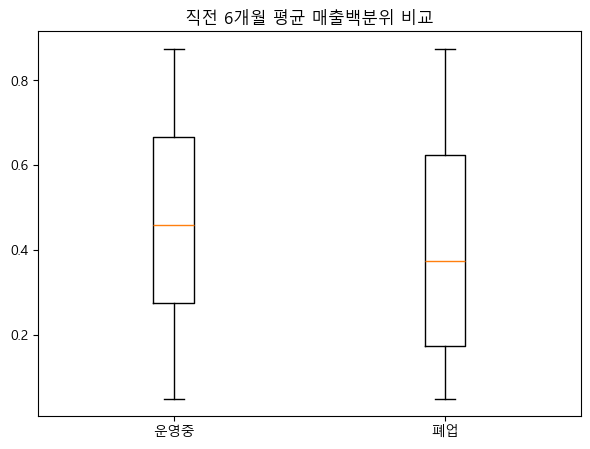

In [37]:
# 1) 폐업/생존 요약 테이블의 컬럼명을 통일
폐업_요약 = 폐업_요약.rename(columns={
    '폐업_직전6개월_평균매출백분위': '직전6개월_평균매출백분위',
    '폐업_평균감소율(%)': '평균감소율(%)'
})
폐업_요약['폐업여부'] = 1

생존_요약['폐업여부'] = 0

# 2) 두 집단 결합
compare_df = pd.concat([생존_요약, 폐업_요약], ignore_index=True)

# 3) 실제로 값이 있는지 최종 점검(둘 다 0보다 커야 정상)
print("생존 표본수:", compare_df.query("폐업여부==0")['직전6개월_평균매출백분위'].notna().sum())
print("폐업 표본수:", compare_df.query("폐업여부==1")['직전6개월_평균매출백분위'].notna().sum())

# 4) 그리기 (한글 폰트 설정 유지)
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

alive_vals = compare_df.loc[compare_df['폐업여부']==0,'직전6개월_평균매출백분위'].astype(float).dropna().values
closed_vals = compare_df.loc[compare_df['폐업여부']==1,'직전6개월_평균매출백분위'].astype(float).dropna().values

plt.figure(figsize=(7,5))
plt.boxplot([alive_vals, closed_vals], tick_labels=['운영중','폐업'])
plt.title('직전 6개월 평균 매출백분위 비교')
plt.show()


In [39]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
     --------------------------------------- 38.7/38.7 MB 10.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
from scipy.stats import ttest_ind

alive_vals = compare_df.loc[compare_df['폐업여부']==0,'직전6개월_평균매출백분위'].dropna()
closed_vals = compare_df.loc[compare_df['폐업여부']==1,'직전6개월_평균매출백분위'].dropna()

t_stat, p_val = ttest_ind(alive_vals, closed_vals, equal_var=False)
print(f"t-통계량: {t_stat:.3f},  p-value: {p_val:.5f}")

if p_val < 0.05:
    print("✅ 유의미한 차이 있음 (p<0.05)")
else:
    print("⚪ 통계적으로 유의미한 차이는 없음")


t-통계량: 1.881,  p-value: 0.06231
⚪ 통계적으로 유의미한 차이는 없음


### 6. 폐업가게 변수 추이

In [57]:
import pandas as pd
import numpy as np

dfc = df_merged.copy()

# 1) 기준년월은 안전하게 datetime
dfc['기준년월'] = pd.to_datetime(dfc['기준년월'], errors='coerce')

# 2) 폐업일: 어떤 형태든 숫자만 추출해서 마지막 8자리를 YYYYMMDD로 해석
tmp = dfc['폐업일'].astype(str).str.replace(r'\D', '', regex=True)  # 숫자만 남김
# 길이가 8 미만이면 파싱 불가로 처리
mask8 = tmp.str.len() >= 8
yyyymmdd = tmp.where(mask8).str[-8:]  # 마지막 8자리만 사용

dfc['폐업일'] = pd.to_datetime(yyyymmdd, format='%Y%m%d', errors='coerce')

print("▶ 복구 후 폐업일 notna:", dfc['폐업일'].notna().sum())
print("▶ 복구 후 폐업일 범위:", dfc['폐업일'].min(), "→", dfc['폐업일'].max())


▶ 복구 후 폐업일 notna: 2334
▶ 복구 후 폐업일 범위: 2023-01-05 00:00:00 → 2025-08-22 00:00:00


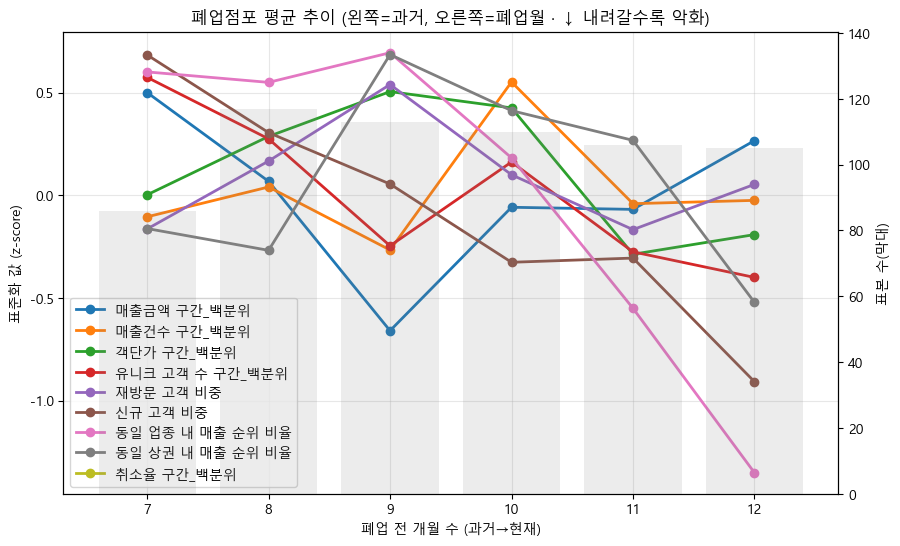

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ===== 파라미터 =====
N = 12         # 과거 N개월~폐업월(0)까지
MIN_CNT = 50   # 해당 구간 표본 최소 개수
SMOOTH = 3     # 1이면 스무딩 없음(3~5 권장)

# 1️⃣ 폐업점포만 + 폐업월까지의 기록만
closed = dfc[dfc['폐업일'].notna()].copy()
closed = closed[closed['기준년월'] <= closed['폐업일']].copy()

# 2️⃣ 폐업까지 남은 개월(0=폐업월)
closed['폐업까지_개월'] = (
    (closed['폐업일'].dt.year - closed['기준년월'].dt.year) * 12 +
    (closed['폐업일'].dt.month - closed['기준년월'].dt.month)
)

# 3️⃣ 분석 대상 변수
vars_to_plot = [
    '매출금액 구간_백분위',
    '매출건수 구간_백분위',
    '객단가 구간_백분위',
    '유니크 고객 수 구간_백분위',
    '재방문 고객 비중',
    '신규 고객 비중',
    '동일 업종 내 매출 순위 비율',
    '동일 상권 내 매출 순위 비율',
    '취소율 구간_백분위'
]
vars_to_plot = [c for c in vars_to_plot if c in closed.columns]

# 4️⃣ 분석 구간(0~N개월) + 표본 수 필터
closedN = closed[closed['폐업까지_개월'].between(0, N)].copy()
cnt = closedN['폐업까지_개월'].value_counts().sort_index()
valid_months = cnt[cnt >= MIN_CNT].index
closedN = closedN[closedN['폐업까지_개월'].isin(valid_months)]

# 5️⃣ 월별 평균(폐업까지_개월 기준)
trend = (
    closedN.groupby('폐업까지_개월')[vars_to_plot]
    .mean()
    .sort_index()
)

# 6️⃣ z-score 표준화 (비교용)
trend_z = (trend - trend.mean()) / trend.std(ddof=0)

# 7️⃣ 스무딩
if SMOOTH > 1:
    trend_z = trend_z.rolling(window=SMOOTH, min_periods=1, center=True).mean()

# 8️⃣ x축 정렬: 왼쪽=과거, 오른쪽=폐업월(0)
trend_z = trend_z.sort_index(ascending=False)
cnt_plot = cnt.reindex(trend_z.index).fillna(0)

# 9️⃣ 그래프
fig, ax1 = plt.subplots(figsize=(10,6))

for col in trend_z.columns:
    ax1.plot(trend_z.index, trend_z[col], marker='o', linewidth=2, label=col)

ax1.set_title('폐업점포 평균 추이 (왼쪽=과거, 오른쪽=폐업월 · ↓ 내려갈수록 악화)')
ax1.set_xlabel('폐업 전 개월 수 (과거→현재)')
ax1.set_ylabel('표준화 값 (z-score)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 표본 수(회색 막대)
ax2 = ax1.twinx()
ax2.bar(cnt_plot.index, cnt_plot.values, alpha=0.15, color='gray', width=0.8)
ax2.set_ylabel('표본 수(막대)')
ax2.set_ylim(0, max(cnt_plot.values) * 1.2 if len(cnt_plot) else 1)

plt.show()


In [63]:
# 🔹 변화량 계산: 과거 평균 - 최근 평균
past_mean = trend_z.iloc[:6].mean()   # 과거 6개월 평균 (왼쪽)
recent_mean = trend_z.iloc[-2:].mean()  # 최근 2개월 평균 (폐업 직전)
diff = recent_mean - past_mean  # 최근 - 과거

# 🔹 정렬 (감소폭이 큰 순)
diff = past_mean - recent_mean  # 과거 - 최근
impact_rank = diff.sort_values(ascending=False)  # 하락이 클수록 악화

impact_df = pd.DataFrame({
    '변수': impact_rank.index,
    '폐업_직전6개월_변화량(z-score)': impact_rank.values,
    '영향도(↓감소 클수록 악화)': -impact_rank.values
})
impact_df.sort_values('폐업_직전6개월_변화량(z-score)').reset_index(drop=True)


,변수,폐업_직전6개월_변화량(z-score),영향도(↓감소 클수록 악화)
0,신규 고객 비중,-0.577340,0.577340
1,동일 업종 내 매출 순위 비율,-0.554598,0.554598
2,유니크 고객 수 구간_백분위,-0.409787,0.409787
3,매출금액 구간_백분위,-0.276319,0.276319
4,객단가 구간_백분위,-0.021026,0.021026
5,매출건수 구간_백분위,0.058148,-0.058148
6,재방문 고객 비중,0.086695,-0.086695
7,동일 상권 내 매출 순위 비율,0.284071,-0.284071
8,취소율 구간_백분위,NaN,NaN


## 매출과 다른 변수의 상관관계

### 1. 상관계수

In [45]:
num_cols = df_merged.select_dtypes(include=['float64', 'int64']).columns
corr_df = df_merged[num_cols]

target = '매출금액 구간_백분위'
corr_matrix = corr_df.corr()
target_corr = corr_matrix[target].sort_values(ascending=False)

print('=== 매출금액 구간_백분위와의 상관계수 ===')
print(target_corr)


=== 매출금액 구간_백분위와의 상관계수 ===
매출금액 구간_백분위          1.000000
동일 업종 내 매출 순위 비율     0.776841
유니크 고객 수 구간_백분위      0.723746
매출건수 구간_백분위          0.695777
배달매출금액 비율            0.513939
동일 상권 내 매출 순위 비율     0.445186
객단가 구간_백분위           0.362049
거주 이용 고객 비율          0.139136
재방문 고객 비중            0.025374
가맹점 운영개월수 구간_백분위     0.024069
재방문 고객 비중_전월증감      -0.019052
신규 고객 비중            -0.040343
신규 고객 비중_전월증감       -0.056018
직장 이용 고객 비율         -0.064457
매출금액 구간_전월증감        -0.070189
동일 상권 내 해지 가맹점 비중   -0.131179
동일 업종 내 해지 가맹점 비중   -0.166837
매출금액 구간_회복지수_6개월    -0.479427
동일 업종 매출건수 비율       -0.555712
동일 업종 매출금액 비율       -0.826959
취소율 구간_백분위                NaN
Name: 매출금액 구간_백분위, dtype: float64


### 2. 매출 급감 원인 분석

In [47]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 8.9/8.9 MB 11.2 MB/s eta 0:00:00
     -------------------------------------- 308.4/308.4 kB 9.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1️⃣ 타깃 생성 (완화 버전)
df_merged = df_merged.sort_values(['가맹점구분번호','기준년월']).reset_index(drop=True)
g = df_merged.groupby('가맹점구분번호', group_keys=False)
df_merged['최근3개월_평균'] = g['매출금액 구간_백분위'].transform(lambda s: s.rolling(3).mean())
df_merged['전년동월'] = g['매출금액 구간_백분위'].shift(12)
df_merged['전년동월대비변화율(%)'] = (df_merged['최근3개월_평균'] - df_merged['전년동월']) / df_merged['전년동월'] * 100

# 💡 급감 기준 완화 (-30 → -20)
df_merged['급감'] = (df_merged['전년동월대비변화율(%)'] <= -20).astype(int)

print("✅ 급감(=1) 정의: 전년동월 대비 평균 매출 –20% 이하 감소")
print("급감 표본 분포:\n", df_merged['급감'].value_counts())

# 2️⃣ 특징 후보
feature_cols = [
    '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율',
    '유니크 고객 수 구간_백분위', '매출건수 구간_백분위', '객단가 구간_백분위',
    '배달매출금액 비율', '재방문 고객 비중', '신규 고객 비중',
    '거주 이용 고객 비율', '직장 이용 고객 비율',
    '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중',
    '매출금액 구간_회복지수_6개월'
]
feature_cols = [c for c in feature_cols if c in df_merged.columns]
X_raw = df_merged[feature_cols].copy()
y = df_merged['급감']

# 3️⃣ 결측 대체 + 스케일
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imputed)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 4️⃣ 랜덤포레스트
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
imp_df = pd.DataFrame({'변수': feature_cols, '중요도': importances}).sort_values('중요도', ascending=False)

print("\n=== 📊 매출 급감 영향 요인 상위 10 ===")
display(imp_df.head(10))

print("\n=== 🎯 분류 성능 (RandomForest) ===")
print(classification_report(y_test, rf.predict(X_test)))

# 5️⃣ 로지스틱 회귀로 방향 확인
lr = LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train, y_train)
coef_df = pd.DataFrame({'변수': feature_cols, '계수(양수=급감↑)': lr.coef_[0]}).sort_values('계수(양수=급감↑)', ascending=False)

print("\n=== ⚖️ 매출 급감에 대한 영향 방향 (로지스틱 회귀 계수) ===")
display(coef_df)


✅ 급감(=1) 정의: 전년동월 대비 평균 매출 –20% 이하 감소
급감 표본 분포:
 급감
0    82741
1     3849
Name: count, dtype: int64

=== 📊 매출 급감 영향 요인 상위 10 ===


,변수,중요도
0,동일 업종 내 매출 순위 비율,0.132521
6,재방문 고객 비중,0.126358
7,신규 고객 비중,0.115201
8,거주 이용 고객 비율,0.105285
1,동일 상권 내 매출 순위 비율,0.098249
10,동일 업종 내 해지 가맹점 비중,0.097991
9,직장 이용 고객 비율,0.093094
11,동일 상권 내 해지 가맹점 비중,0.068084
5,배달매출금액 비율,0.052918
12,매출금액 구간_회복지수_6개월,0.032176



=== 🎯 분류 성능 (RandomForest) ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     24822
           1       0.48      0.01      0.03      1155

    accuracy                           0.96     25977
   macro avg       0.72      0.51      0.50     25977
weighted avg       0.94      0.96      0.93     25977


=== ⚖️ 매출 급감에 대한 영향 방향 (로지스틱 회귀 계수) ===


,변수,계수(양수=급감↑)
12,매출금액 구간_회복지수_6개월,0.406658
6,재방문 고객 비중,0.138733
10,동일 업종 내 해지 가맹점 비중,0.059336
1,동일 상권 내 매출 순위 비율,0.030726
2,유니크 고객 수 구간_백분위,0.008596
3,매출건수 구간_백분위,-0.016433
9,직장 이용 고객 비율,-0.024688
11,동일 상권 내 해지 가맹점 비중,-0.086773
8,거주 이용 고객 비율,-0.099662
5,배달매출금액 비율,-0.100917


## 매출 관련 가설 기반 분석모델

### 1. 월 매출금액 감소율

In [64]:
df['매출금액_감소율'] = df.groupby('가맹점구분번호')['매출금액 구간_백분위'].pct_change()

C:\Users\askie\AppData\Local\Temp\ipykernel_77944\1014444312.py:1: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['매출금액_감소율'] = df.groupby('가맹점구분번호')['매출금액 구간_백분위'].pct_change()


가설: 신규 고객 유입이 줄어들수록 매출금액이 감소한다

✅ 매출감소율 계산 완료 — NaN 포함 행 수: 8213
✅ 학습용 데이터 크기: (8043, 12)

=== 📊 변수별 상관계수 (매출금액 감소율과의 관계) ===
                       상관계수
객단가 구간_백분위         0.020592
동일 상권 내 해지 가맹점 비중  0.012508
동일 업종 내 해지 가맹점 비중  0.009036
재방문 고객 비중          0.003608
매출건수 구간_백분위       -0.004065
유니크 고객 수 구간_백분위   -0.008001
배달매출금액 비율         -0.016525
동일 상권 내 매출 순위 비율  -0.117321
동일 업종 내 매출 순위 비율  -0.121881
신규 고객 비중          -0.142937
매출금액 구간_회복지수_6개월  -0.525960

=== ⚖️ 회귀계수 (양수=감소율 완화, 음수=감소율 심화) ===
                   변수      회귀계수
2     유니크 고객 수 구간_백분위  0.012723
0            신규 고객 비중  0.003129
9   동일 상권 내 해지 가맹점 비중  0.001160
4           배달매출금액 비율 -0.000006
8   동일 업종 내 해지 가맹점 비중 -0.000126
5    동일 업종 내 매출 순위 비율 -0.000390
1           재방문 고객 비중 -0.000450
6    동일 상권 내 매출 순위 비율 -0.001151
3          객단가 구간_백분위 -0.082445
7         매출건수 구간_백분위 -0.136598
10   매출금액 구간_회복지수_6개월 -0.467571


C:\Users\askie\AppData\Local\Temp\ipykernel_77944\39490533.py:17: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['매출금액_감소율'] = df.groupby('가맹점구분번호')['매출금액 구간_백분위'].pct_change()


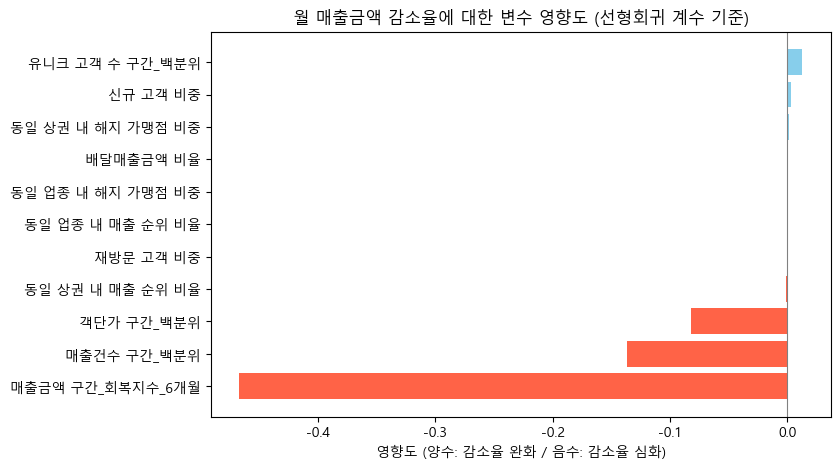

In [65]:
# =========================
# 🧩 월 매출금액 감소율 분석
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# -------------------------
# 1️⃣ 종속변수(Y) 계산
# -------------------------
df = df_merged.copy()
df = df.sort_values(['가맹점구분번호','기준년월'])

# 전월 대비 매출금액 구간 변화율 (감소율)
df['매출금액_감소율'] = df.groupby('가맹점구분번호')['매출금액 구간_백분위'].pct_change()

print(f"✅ 매출감소율 계산 완료 — NaN 포함 행 수: {df['매출금액_감소율'].isna().sum()}")

# -------------------------
# 2️⃣ 독립변수(X) 설정
# -------------------------
feature_cols = [
    '신규 고객 비중', '재방문 고객 비중', '유니크 고객 수 구간_백분위',
    '객단가 구간_백분위', '배달매출금액 비율',
    '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율',
    '매출건수 구간_백분위',
    '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중',
    '매출금액 구간_회복지수_6개월'
]

# 필요한 컬럼만 추출
df_model = df[feature_cols + ['매출금액_감소율']].dropna()

print(f"✅ 학습용 데이터 크기: {df_model.shape}")

# -------------------------
# 3️⃣ 상관분석
# -------------------------
corrs = {}
for col in feature_cols:
    corr, _ = pearsonr(df_model[col], df_model['매출금액_감소율'])
    corrs[col] = corr

corr_df = pd.DataFrame.from_dict(corrs, orient='index', columns=['상관계수']).sort_values('상관계수', ascending=False)
print("\n=== 📊 변수별 상관계수 (매출금액 감소율과의 관계) ===")
print(corr_df)

# -------------------------
# 4️⃣ 선형회귀로 영향도 분석
# -------------------------
X = df_model[feature_cols]
y = df_model['매출금액_감소율']

model = LinearRegression()
model.fit(X, y)

coef_df = pd.DataFrame({
    '변수': feature_cols,
    '회귀계수': model.coef_
}).sort_values('회귀계수', ascending=False)

print("\n=== ⚖️ 회귀계수 (양수=감소율 완화, 음수=감소율 심화) ===")
print(coef_df)

# -------------------------
# 5️⃣ 시각화
# -------------------------
plt.figure(figsize=(8,5))
plt.barh(coef_df['변수'], coef_df['회귀계수'], color=['tomato' if v<0 else 'skyblue' for v in coef_df['회귀계수']])
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('월 매출금액 감소율에 대한 변수 영향도 (선형회귀 계수 기준)')
plt.xlabel('영향도 (양수: 감소율 완화 / 음수: 감소율 심화)')
plt.gca().invert_yaxis()
plt.show()


매출이 많이 줄어든 매장 vs 안정적인 매장

✅ 비교대상 데이터 수: 8043 (급감 1774 / 안정 6269)

=== 📊 매출감소율 상/하위 20% 그룹 평균 비교 (t-test) ===
                   변수    급감그룹 평균    안정그룹 평균  차이(급감-안정)       p-value
0            신규 고객 비중   6.069216   9.343573  -3.274357  6.644310e-99
5    동일 업종 내 매출 순위 비율  31.643461  32.837869  -1.194408  5.308513e-02
6    동일 상권 내 매출 순위 비율  34.236584  35.017020  -0.780436  1.061932e-01
10   매출금액 구간_회복지수_6개월   0.028141   0.638058  -0.609917  0.000000e+00
1           재방문 고객 비중  22.831657  22.865741  -0.034084  9.021631e-01
8   동일 업종 내 해지 가맹점 비중  17.188557  17.175164   0.013393  8.608581e-01
9   동일 상권 내 해지 가맹점 비중   8.823450   8.801563   0.021887  4.753246e-01
3          객단가 구간_백분위   0.542334   0.512255   0.030079  1.476989e-07
7         매출건수 구간_백분위   0.514825   0.469628   0.045197  3.881085e-13
2     유니크 고객 수 구간_백분위   0.508822   0.462562   0.046260  6.689289e-14
4           배달매출금액 비율  34.439402  29.733227   4.706175  2.541468e-07


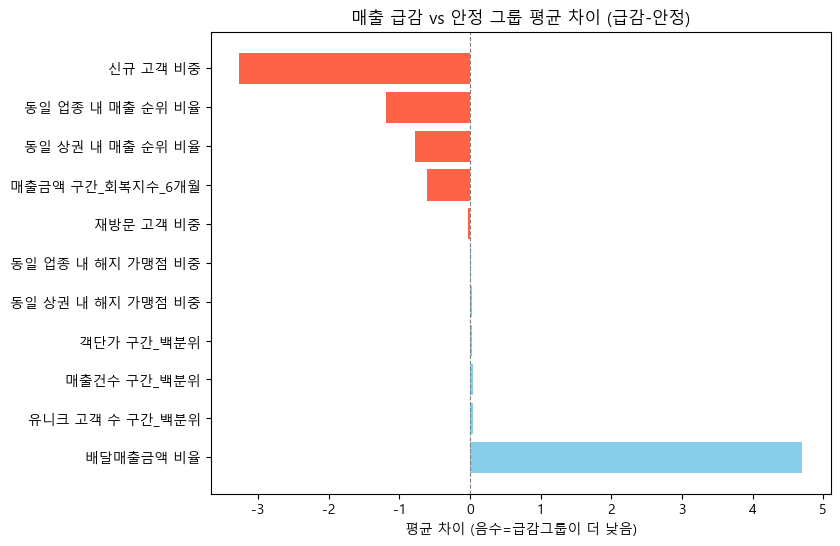

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 0) 준비: df_model 은 이전 셀에서 만든 (특징 + 매출금액_감소율) 데이터프레임
df_temp = df_model.copy()

# 1) 상/하위 20% 경계값
lower_thr = df_temp['매출금액_감소율'].quantile(0.2)
upper_thr = df_temp['매출금액_감소율'].quantile(0.8)

# 2) dtype 충돌 없이 라벨링
grp = pd.Series(np.nan, index=df_temp.index, dtype="object")
grp[df_temp['매출금액_감소율'] <= lower_thr] = '하위20%(안정)'
grp[df_temp['매출금액_감소율'] >= upper_thr] = '상위20%(급감)'
df_temp['감소율_그룹'] = grp

# 3) 비교 대상만 필터
df_groups = df_temp.dropna(subset=['감소율_그룹'])
n_hi = (df_groups['감소율_그룹']=='상위20%(급감)').sum()
n_lo = (df_groups['감소율_그룹']=='하위20%(안정)').sum()
print(f"✅ 비교대상 데이터 수: {len(df_groups)} (급감 {n_hi} / 안정 {n_lo})")

# 4) t-test
result_list = []
for col in feature_cols:
    g_hi = df_groups.loc[df_groups['감소율_그룹']=='상위20%(급감)', col].dropna()
    g_lo = df_groups.loc[df_groups['감소율_그룹']=='하위20%(안정)', col].dropna()
    # 표본 수 체크
    if len(g_hi) > 30 and len(g_lo) > 30:
        t, p = ttest_ind(g_hi, g_lo, equal_var=False)
        diff = g_hi.mean() - g_lo.mean()
        result_list.append([col, g_hi.mean(), g_lo.mean(), diff, p])

result_df = pd.DataFrame(
    result_list,
    columns=['변수','급감그룹 평균','안정그룹 평균','차이(급감-안정)','p-value']
).sort_values('차이(급감-안정)')

print("\n=== 📊 매출감소율 상/하위 20% 그룹 평균 비교 (t-test) ===")
print(result_df)

# 5) 시각화
plt.figure(figsize=(8,6))
colors = ['tomato' if x < 0 else 'skyblue' for x in result_df['차이(급감-안정)']]
plt.barh(result_df['변수'], result_df['차이(급감-안정)'], color=colors)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('매출 급감 vs 안정 그룹 평균 차이 (급감-안정)')
plt.xlabel('평균 차이 (음수=급감그룹이 더 낮음)')
plt.gca().invert_yaxis()
plt.show()


신규가설:
“신규 고객 유입률이 낮고, 회복지수가 떨어지며, 배달매출 비율이 높은 매장은 월 매출 감소율이 커진다.”

- 종속변수: 매출감소율이 상위 20% 이상(급감=1)
- 독립변수: 신규 고객 비중, 회복지수, 배달비율, 매출건수, 유니크 고객 등
- 모델: 랜덤포레스트 + 로지스틱회귀 (변수중요도 + 방향성 모두 확인)

In [68]:
# ============================================
# 💡 매출감소 예측모델 (RandomForest + LogisticRegression)
# ============================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------
# 1️⃣ 종속변수 생성 (상위20% = 급감=1)
# -------------------------
df_model2 = df_model.copy()

upper_thr = df_model2['매출금액_감소율'].quantile(0.8)
df_model2['매출급감여부'] = (df_model2['매출금액_감소율'] >= upper_thr).astype(int)

print("✅ 급감=1 / 정상=0 분포:")
print(df_model2['매출급감여부'].value_counts())

# -------------------------
# 2️⃣ 독립변수 선택
# -------------------------
X_cols = [
    '신규 고객 비중', '재방문 고객 비중', '배달매출금액 비율',
    '유니크 고객 수 구간_백분위', '매출건수 구간_백분위', '객단가 구간_백분위',
    '매출금액 구간_회복지수_6개월', '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율'
]

X = df_model2[X_cols].fillna(df_model2[X_cols].median())
y = df_model2['매출급감여부']

# -------------------------
# 3️⃣ 데이터 분할 & 스케일링
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# 4️⃣ 랜덤포레스트 학습
# -------------------------
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=300)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_imp = pd.DataFrame({
    '변수': X_cols,
    '중요도': rf.feature_importances_
}).sort_values('중요도', ascending=False)

print("\n=== 🔥 RandomForest 변수 중요도 상위 ===")
print(rf_imp)

# -------------------------
# 5️⃣ 로지스틱 회귀 (방향성 확인)
# -------------------------
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_coef = pd.DataFrame({
    '변수': X_cols,
    '회귀계수(양수=급감↑)': lr.coef_[0]
}).sort_values('회귀계수(양수=급감↑)', ascending=False)

print("\n=== ⚖️ LogisticRegression 변수 계수 ===")
print(lr_coef)

# -------------------------
# 6️⃣ 예측 성능
# -------------------------
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print("\n=== 🎯 모델 성능 (RandomForest) ===")
print(classification_report(y_test, rf_pred))
print(f"AUC 점수: {rf_auc:.3f}")


✅ 급감=1 / 정상=0 분포:
매출급감여부
0    6269
1    1774
Name: count, dtype: int64

=== 🔥 RandomForest 변수 중요도 상위 ===
                 변수       중요도
6  매출금액 구간_회복지수_6개월  0.414902
0          신규 고객 비중  0.137253
7  동일 업종 내 매출 순위 비율  0.105881
8  동일 상권 내 매출 순위 비율  0.103600
1         재방문 고객 비중  0.102056
2         배달매출금액 비율  0.086661
5        객단가 구간_백분위  0.021334
4       매출건수 구간_백분위  0.014312
3   유니크 고객 수 구간_백분위  0.014002

=== ⚖️ LogisticRegression 변수 계수 ===
                 변수  회귀계수(양수=급감↑)
3   유니크 고객 수 구간_백분위      0.237894
0          신규 고객 비중      0.174449
7  동일 업종 내 매출 순위 비율      0.030724
2         배달매출금액 비율      0.020429
5        객단가 구간_백분위     -0.024863
8  동일 상권 내 매출 순위 비율     -0.052614
1         재방문 고객 비중     -0.056253
4       매출건수 구간_백분위     -0.284396
6  매출금액 구간_회복지수_6개월     -2.324815

=== 🎯 모델 성능 (RandomForest) ===
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1881
           1       0.49      0.30      0.38       532

    accuracy          

### 2. 전년 동월 대비 매출 증감률

- 종속변수	매출금액_전년동월증감률 (percent change from same month last year)
- 독립변수	고객 비중, 순위, 배달비율, 회복지수 등
- 가설	“회복력·신규고객 비중·상권순위가 낮은 매장은 전년 대비 매출 성장률이 낮다.”

In [70]:
# ============================================
# 전년 동월 대비 매출 증감률 분석 (df_merged 기반)
# ============================================
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 0) 사용 컬럼 정의
feature_cols = [
    '신규 고객 비중', '재방문 고객 비중', '유니크 고객 수 구간_백분위',
    '객단가 구간_백분위', '배달매출금액 비율', '매출건수 구간_백분위',
    '매출금액 구간_회복지수_6개월', '동일 업종 내 매출 순위 비율',
    '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중'
]

base_cols = ['가맹점구분번호', '기준년월', '매출금액 구간_백분위'] + feature_cols

# 1) 원본에서 필요한 컬럼만 추출
df_year = df_merged[base_cols].copy()

# 2) 기준년월 datetime 변환 + 정렬
df_year['기준년월'] = pd.to_datetime(df_year['기준년월'])
df_year = df_year.sort_values(['가맹점구분번호', '기준년월'])

# 3) 전년 동월 대비 매출금액 백분위 증감률(%) 계산
df_year['매출금액_전년동월증감'] = (
    df_year.groupby('가맹점구분번호')['매출금액 구간_백분위']
           .pct_change(periods=12) * 100
)

print(f"✅ 전년 동월 대비 매출 증감 계산 완료 — NaN 행: {df_year['매출금액_전년동월증감'].isna().sum()}")

# 4) 모델 데이터셋 구성 (결측 제거)
cols = ['매출금액_전년동월증감'] + feature_cols
df_year_model = df_year[cols].dropna()
print(f"✅ 학습용 데이터 크기: {df_year_model.shape}")

# 5) 단순 선형회귀로 영향도 파악
X = df_year_model.drop('매출금액_전년동월증감', axis=1)
y = df_year_model['매출금액_전년동월증감']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# R² (설명력)
r2 = r2_score(y, y_pred)

coef_df = (
    pd.DataFrame({'변수': X.columns, '회귀계수(양수=전년대비 성장↑, 음수=감소↓)': model.coef_})
      .sort_values('회귀계수(양수=전년대비 성장↑, 음수=감소↓)', ascending=False)
      .reset_index(drop=True)
)

print("\n=== 📈 전년 동월 대비 매출 증감률 영향 요인 (선형회귀 계수) ===")
print(coef_df)
print(f"\n모델 설명력 R²: {r2:.3f}")


✅ 전년 동월 대비 매출 증감 계산 완료 — NaN 행: 49474
✅ 학습용 데이터 크기: (4131, 12)

=== 📈 전년 동월 대비 매출 증감률 영향 요인 (선형회귀 계수) ===
                   변수  회귀계수(양수=전년대비 성장↑, 음수=감소↓)
0          객단가 구간_백분위                  65.994392
1         매출건수 구간_백분위                  48.389587
2     유니크 고객 수 구간_백분위                  30.361050
3   동일 상권 내 해지 가맹점 비중                   5.002372
4   동일 업종 내 해지 가맹점 비중                   0.677049
5           배달매출금액 비율                   0.134787
6            신규 고객 비중                  -0.262654
7    동일 업종 내 매출 순위 비율                  -0.325461
8           재방문 고객 비중                  -0.453488
9    동일 상권 내 매출 순위 비율                  -1.064370
10   매출금액 구간_회복지수_6개월                 -35.173843

모델 설명력 R²: 0.280


C:\Users\askie\AppData\Local\Temp\ipykernel_77944\382648144.py:29: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(periods=12) * 100


결과: 위험도 예측보다는 추후 방향성 제시에 적합할 듯

### 3. 매출 안정성 지수


- 종속변수 (y) 최근 6개월 표준편차
- 독립변수 (X) 매출금액 구간_회복지수_6개월, 신규/재방문 고객 비중, 유니크 고객 수 구간_백분위, 객단가, 배달비율, 상권/업종 해지비중, 상권/업종 내 매출순위 등
- 예시 가설: 회복지수가 낮고 고객층이 한쪽에 치우친 매장은 매출 변동성이 크다.


In [71]:
# ============================================
# 📊 매출 안정성 지수 (Revenue Stability Index)
# ============================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1️⃣ 기본 변수 세팅
features = [
    '신규 고객 비중', '재방문 고객 비중', '유니크 고객 수 구간_백분위',
    '객단가 구간_백분위', '배달매출금액 비율', '매출건수 구간_백분위',
    '매출금액 구간_회복지수_6개월', '동일 업종 내 매출 순위 비율',
    '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
    '동일 상권 내 해지 가맹점 비중'
]

df_var = df_merged[['가맹점구분번호','기준년월','매출금액 구간_백분위'] + features].copy()
df_var['기준년월'] = pd.to_datetime(df_var['기준년월'])
df_var = df_var.sort_values(['가맹점구분번호','기준년월'])

# 2️⃣ 최근 6개월 매출 변동성(표준편차) 계산
df_var['매출_6개월_std'] = (
    df_var.groupby('가맹점구분번호')['매출금액 구간_백분위']
          .transform(lambda x: x.rolling(window=6, min_periods=3).std())
)

# 3️⃣ 최근 시점만 추출 (각 가맹점의 마지막 달)
df_latest = df_var.groupby('가맹점구분번호').tail(1)

# 4️⃣ 변동성 상위 20% → 불안정(1), 하위 80% → 안정(0)
thr = df_latest['매출_6개월_std'].quantile(0.8)
df_latest['불안정여부'] = (df_latest['매출_6개월_std'] >= thr).astype(int)

print(f"✅ 분석용 데이터 수: {df_latest.shape[0]}")
print(df_latest['불안정여부'].value_counts())

# 5️⃣ 학습 데이터 구성
X = df_latest[features].fillna(0)
y = df_latest['불안정여부']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# 6️⃣ 랜덤포레스트로 변수 중요도 확인
rf = RandomForestClassifier(random_state=42, n_estimators=300, max_depth=5)
rf.fit(X_train, y_train)

importances = pd.DataFrame({
    '변수': features,
    '중요도': rf.feature_importances_
}).sort_values('중요도', ascending=False)

print("\n=== 🔥 매출 안정성(변동성↑) 영향 요인 상위 ===")
print(importances.head(10))

# 7️⃣ 로지스틱 회귀로 영향 방향(양수=불안정↑, 음수=안정↑)
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

coef_df = pd.DataFrame({
    '변수': features,
    '계수(양수=불안정↑, 음수=안정↑)': logit.coef_[0]
}).sort_values('계수(양수=불안정↑, 음수=안정↑)', ascending=False)

print("\n=== ⚖️ 불안정성 영향 방향 (로지스틱 회귀 계수) ===")
print(coef_df)

# 8️⃣ 모델 성능 요약
y_pred = rf.predict(X_test)
print("\n=== 🎯 분류 성능 (RandomForest) ===")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")


C:\Users\askie\AppData\Local\Temp\ipykernel_77944\2040227984.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_latest['불안정여부'] = (df_latest['매출_6개월_std'] >= thr).astype(int)


✅ 분석용 데이터 수: 4185
불안정여부
0    3419
1     766
Name: count, dtype: int64

=== 🔥 매출 안정성(변동성↑) 영향 요인 상위 ===
                  변수       중요도
6   매출금액 구간_회복지수_6개월  0.311165
7   동일 업종 내 매출 순위 비율  0.191790
8   동일 상권 내 매출 순위 비율  0.142033
0           신규 고객 비중  0.110610
3         객단가 구간_백분위  0.061005
2    유니크 고객 수 구간_백분위  0.038479
9  동일 업종 내 해지 가맹점 비중  0.036383
5        매출건수 구간_백분위  0.036355
1          재방문 고객 비중  0.034415
4          배달매출금액 비율  0.018917

=== ⚖️ 불안정성 영향 방향 (로지스틱 회귀 계수) ===
                   변수  계수(양수=불안정↑, 음수=안정↑)
6    매출금액 구간_회복지수_6개월             0.647602
5         매출건수 구간_백분위             0.528793
2     유니크 고객 수 구간_백분위             0.311038
0            신규 고객 비중             0.237038
3          객단가 구간_백분위             0.217406
1           재방문 고객 비중             0.168434
8    동일 상권 내 매출 순위 비율             0.116701
9   동일 업종 내 해지 가맹점 비중            -0.007298
10  동일 상권 내 해지 가맹점 비중            -0.087894
4           배달매출금액 비율            -0.200792
7    동일 업종 내 매출 순위 비율            -0.827885

===

C:\Users\askie\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


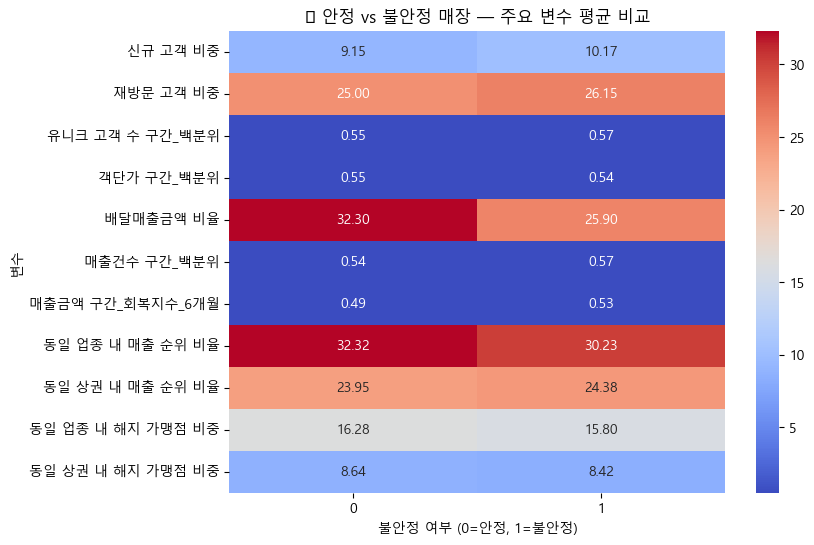

C:\Users\askie\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


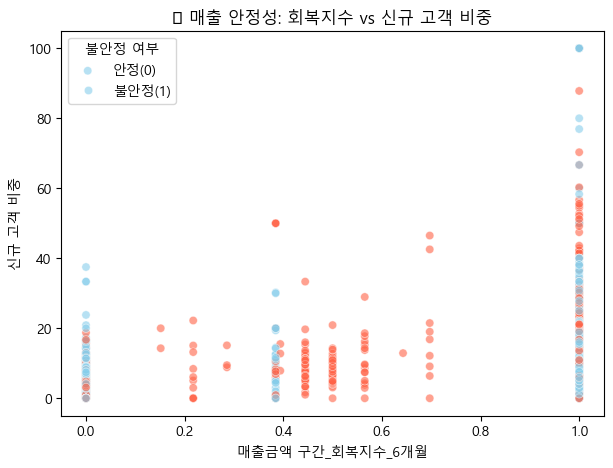

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1️⃣ 그룹별 평균 비교 Heatmap
# ============================================
group_means = df_latest.groupby('불안정여부')[features].mean().T
plt.figure(figsize=(8,6))
sns.heatmap(group_means, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('📊 안정 vs 불안정 매장 — 주요 변수 평균 비교')
plt.ylabel('변수')
plt.xlabel('불안정 여부 (0=안정, 1=불안정)')
plt.show()

# ============================================
# 2️⃣ 회복지수 vs 신규 고객 비중 Scatter Plot
# ============================================
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_latest,
    x='매출금액 구간_회복지수_6개월',
    y='신규 고객 비중',
    hue='불안정여부',
    palette={0: 'skyblue', 1: 'tomato'},
    alpha=0.6
)
plt.title('📉 매출 안정성: 회복지수 vs 신규 고객 비중')
plt.xlabel('매출금액 구간_회복지수_6개월')
plt.ylabel('신규 고객 비중')
plt.legend(title='불안정 여부', labels=['안정(0)', '불안정(1)'])
plt.show()


### 4. 매출 회복력 지수


- 종속변수 (Y) `매출 회복 여부` → 예: 최근 6개월간 회복지수 평균이 0.6 이상이면 “회복됨(1)”, 아니면 “미회복(0)”                                      |
- 독립변수 (X) 고객/상권/매출 관련 변수들→ `신규 고객 비중`, `재방문 고객 비중`, `배달매출금액 비율`, `동일 업종 내 순위`, `회복추세_6개월`, `극저점_경과개월_6개월` 등
- 가설 (H₀ / H₁) 
- **H₀(귀무가설)**: 고객·상권 변수는 매출 회복 여부에 영향을 미치지 않는다.
- **H₁(대립가설)**: 고객·상권 변수는 매출 회복 여부에 유의한 영향을 미친다.


#### 왜안되지

In [ ]:
import pandas as pd
import numpy as np

# 원본에서 필요한 것만
df_feat = df_merged[['가맹점구분번호','기준년월','매출금액 구간_백분위',
                    '신규 고객 비중','재방문 고객 비중','유니크 고객 수 구간_백분위',
                    '객단가 구간_백분위','배달매출금액 비율','매출건수 구간_백분위',
                    '동일 업종 내 매출 순위 비율','동일 상권 내 매출 순위 비율',
                    '동일 업종 내 해지 가맹점 비중','동일 상권 내 해지 가맹점 비중']].copy()

df_feat['기준년월'] = pd.to_datetime(df_feat['기준년월'])
df_feat = df_feat.sort_values(['가맹점구분번호','기준년월'])

def _recovery(series, w):
    mn = series.rolling(w, min_periods=w).min()
    mx = series.rolling(w, min_periods=w).max()
    denom = (mx - mn).replace(0, np.nan)
    return ((series - mn) / denom).clip(0,1)

def _slope(series, w):
    def f(a):
        if np.isnan(a).any(): return np.nan
        x = np.arange(len(a))
        if np.allclose(a, a[0]): return 0.0
        return np.polyfit(x, a, 1)[0]
    return series.rolling(w, min_periods=w).apply(f, raw=True)

def _months_since_trough(series, w):
    def g(a):
        if np.isnan(a).all(): return np.nan
        pos = np.nanargmin(a)
        return (len(a)-1) - pos
    return series.rolling(w, min_periods=w).apply(g, raw=True)

# 컬럼 생성 (6개월 기준)
df_feat['매출금액 구간_회복지수_6개월'] = df_feat.groupby('가맹점구분번호')['매출금액 구간_백분위'].transform(lambda s: _recovery(s, 6))
df_feat['회복추세_6개월'] = df_feat.groupby('가맹점구분번호')['매출금액 구간_백분위'].transform(lambda s: _slope(s, 6))
df_feat['극저점_경과개월_6개월'] = df_feat.groupby('가맹점구분번호')['매출금액 구간_백분위'].transform(lambda s: _months_since_trough(s, 6))

# 각 가맹점의 최신 스냅샷만 사용
df_snap = (df_feat.sort_values(['가맹점구분번호','기준년월'])
                 .groupby('가맹점구분번호')
                 .tail(1)
                 .reset_index(drop=True))

print("스냅샷 크기:", df_snap.shape)
df_snap.head(3)


스냅샷 크기: (4185, 16)


,가맹점구분번호,기준년월,매출금액 구간_백분위,신규 고객 비중,재방문 고객 비중,유니크 고객 수 구간_백분위,객단가 구간_백분위,배달매출금액 비율,매출건수 구간_백분위,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,동일 업종 내 해지 가맹점 비중,동일 상권 내 해지 가맹점 비중,매출금액 구간_회복지수_6개월,회복추세_6개월,극저점_경과개월_6개월
0,000F03E44A,2024-12-01,0.950,6.52,10.87,0.825,0.825,78.0,0.825,86.8,62.8,17.4,9.0,1.0,-1.837144e-17,3.0
1,002816BA73,2024-12-01,0.375,8.56,10.83,0.625,0.175,NaN,0.625,21.5,20.0,16.2,5.6,NaN,0.000000e+00,5.0
2,003473B465,2024-12-01,0.950,NaN,NaN,0.950,0.950,NaN,0.950,94.9,88.0,16.4,9.0,NaN,0.000000e+00,5.0


#### 이게결과

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 종속변수 생성
df_model = df_snap.copy()
df_model['회복여부'] = (df_model['매출금액 구간_회복지수_6개월'] >= 0.6).astype(int)

# 독립변수 목록
X_cols = [
    '신규 고객 비중','재방문 고객 비중','유니크 고객 수 구간_백분위',
    '객단가 구간_백분위','배달매출금액 비율','매출건수 구간_백분위',
    '동일 업종 내 매출 순위 비율','동일 상권 내 매출 순위 비율',
    '동일 업종 내 해지 가맹점 비중','동일 상권 내 해지 가맹점 비중',
    '회복추세_6개월','극저점_경과개월_6개월'
]

# 실제 존재하는 컬럼만 사용(오타/누락 방지)
use_cols = [c for c in X_cols if c in df_model.columns]
missing = [c for c in X_cols if c not in df_model.columns]
if missing:
    print("⚠️ 누락된 컬럼(모델에서 제외):", missing)

X = df_model[use_cols].fillna(df_model[use_cols].median())
y = df_model['회복여부']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=6, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

print("\n=== 모델 성능 (회복여부 예측) ===")
print(classification_report(y_test, y_pred))
print("AUC:", round(roc_auc_score(y_test, y_prob), 3))

imp = (pd.DataFrame({'변수': use_cols, '중요도': clf.feature_importances_})
         .sort_values('중요도', ascending=False))
print("\n=== 회복여부에 중요한 변수 ===")
print(imp.head(12))



=== 모델 성능 (회복여부 예측) ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       935
           1       0.86      0.96      0.91       321

    accuracy                           0.95      1256
   macro avg       0.92      0.95      0.94      1256
weighted avg       0.95      0.95      0.95      1256

AUC: 0.986

=== 회복여부에 중요한 변수 ===
                   변수       중요도
10           회복추세_6개월  0.591659
11       극저점_경과개월_6개월  0.145578
0            신규 고객 비중  0.134067
6    동일 업종 내 매출 순위 비율  0.038759
1           재방문 고객 비중  0.017079
7    동일 상권 내 매출 순위 비율  0.015764
5         매출건수 구간_백분위  0.014890
2     유니크 고객 수 구간_백분위  0.010604
3          객단가 구간_백분위  0.010287
8   동일 업종 내 해지 가맹점 비중  0.008612
9   동일 상권 내 해지 가맹점 비중  0.006611
4           배달매출금액 비율  0.006090


### 5. 매출 급감 여부

- 종속변수 (Y) 매출급감여부 — 매출감소율 ≤ -30% → 1 (급감), 그 외 0
- 독립변수 (X) 매출 및 고객, 상권 관련 변수들
- 가설: H₁: 신규고객 감소, 재방문고객 감소, 회복지수 하락은 매출 급감 위험을 높인다.

In [77]:
# ============================================
# 💥 매출 급감 여부 예측 모델
# ============================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 1️⃣ 데이터 복사 및 정리
df_drop = df_merged.copy()

# 매출감소율(%) 계산
df_drop = df_drop.sort_values(['가맹점구분번호', '기준년월'])
df_drop['매출감소율'] = df_drop.groupby('가맹점구분번호')['매출금액 구간_백분위'].pct_change() * 100

# 종속변수 생성: 급감 = -30% 이하
df_drop['매출급감여부'] = (df_drop['매출감소율'] <= -30).astype(int)

# 2️⃣ 독립변수 선택
X_cols = [
    '신규 고객 비중', '재방문 고객 비중',
    '유니크 고객 수 구간_백분위', '객단가 구간_백분위',
    '배달매출금액 비율', '매출건수 구간_백분위',
    '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율',
    '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중',
    '매출금액 구간_회복지수_6개월'
]

df_model = df_drop[X_cols + ['매출급감여부']].dropna()

X = df_model[X_cols]
y = df_model['매출급감여부']

print(f"✅ 데이터 크기: {df_model.shape}")
print("급감=1 / 정상=0 분포:\n", y.value_counts())

# 3️⃣ 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4️⃣ RandomForest로 주요 영향 요인 파악
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== ⚡ RandomForest 성능 ===")
print(classification_report(y_test, y_pred_rf))
print("AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))

fi = pd.DataFrame({'변수': X.columns, '중요도': rf.feature_importances_})
fi = fi.sort_values('중요도', ascending=False)
print("\n=== 🔥 변수 중요도 (급감 영향 요인) ===")
print(fi)

# 5️⃣ 로지스틱 회귀로 영향 방향 분석
logit = LogisticRegression(max_iter=500)
logit.fit(X_train, y_train)
coef = pd.DataFrame({
    '변수': X.columns,
    '계수(양수=급감↑, 음수=급감↓)': logit.coef_[0]
}).sort_values('계수(양수=급감↑, 음수=급감↓)', ascending=False)
print("\n=== ⚖️ 영향 방향 (Logistic Regression 계수) ===")
print(coef)


C:\Users\askie\AppData\Local\Temp\ipykernel_77944\2005705161.py:16: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_drop['매출감소율'] = df_drop.groupby('가맹점구분번호')['매출금액 구간_백분위'].pct_change() * 100


✅ 데이터 크기: (8043, 12)
급감=1 / 정상=0 분포:
 매출급감여부
0    6999
1    1044
Name: count, dtype: int64

=== ⚡ RandomForest 성능 ===
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      2100
           1       0.38      0.95      0.54       313

    accuracy                           0.79      2413
   macro avg       0.69      0.86      0.71      2413
weighted avg       0.91      0.79      0.82      2413

AUC: 0.893

=== 🔥 변수 중요도 (급감 영향 요인) ===
                   변수       중요도
10   매출금액 구간_회복지수_6개월  0.530654
7    동일 상권 내 매출 순위 비율  0.100489
6    동일 업종 내 매출 순위 비율  0.086256
2     유니크 고객 수 구간_백분위  0.068949
0            신규 고객 비중  0.067541
5         매출건수 구간_백분위  0.050434
4           배달매출금액 비율  0.035733
3          객단가 구간_백분위  0.021375
1           재방문 고객 비중  0.017938
9   동일 상권 내 해지 가맹점 비중  0.010877
8   동일 업종 내 해지 가맹점 비중  0.009755

=== ⚖️ 영향 방향 (Logistic Regression 계수) ===
                   변수  계수(양수=급감↑, 음수=급감↓)
10   매출금액 구간_회복지수_6개월            4.291040
2   

### 6. 매출 변동성 상위 여부

- 종속변수 (Y)	매출변동성상위여부 — 최근 6개월 매출 표준편차가 상위 20%이면 1, 그 외 0
- 독립변수 (X)	매출 안정성 관련 주요 변수들
- 가설	H₁: 고객층 편중, 업종 내 해지 비중 증가, 회복지수 하락은 매출 변동성을 높인다.

In [78]:
# ============================================
# 📊 매출 변동성 상위 여부 예측 모델
# ============================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 1️⃣ 데이터 정리
df_var = df_merged.copy()
df_var = df_var.sort_values(['가맹점구분번호', '기준년월'])

# 최근 6개월 매출 표준편차 계산
rolling_std = (
    df_var.groupby('가맹점구분번호')['매출금액 구간_백분위']
          .rolling(window=6, min_periods=3)
          .std()
          .reset_index(level=0, drop=True)
)
df_var['매출_6개월표준편차'] = rolling_std

# 종속변수: 상위 20%면 1 (불안정)
upper_thr = df_var['매출_6개월표준편차'].quantile(0.8)
df_var['매출변동성상위여부'] = (df_var['매출_6개월표준편차'] >= upper_thr).astype(int)

# 2️⃣ 독립변수 정의
X_cols = [
    '매출건수 구간_백분위', '객단가 구간_백분위', '배달매출금액 비율',
    '신규 고객 비중', '재방문 고객 비중', '유니크 고객 수 구간_백분위',
    '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율',
    '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중',
    '매출금액 구간_회복지수_6개월'
]

df_var_model = df_var[X_cols + ['매출변동성상위여부']].dropna()

X = df_var_model[X_cols]
y = df_var_model['매출변동성상위여부']

print(f"✅ 데이터 크기: {df_var_model.shape}")
print("불안정=1 / 안정=0 분포:\n", y.value_counts())

# 3️⃣ 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4️⃣ RandomForest로 중요 변수 파악
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== ⚡ RandomForest 성능 ===")
print(classification_report(y_test, y_pred_rf))
print("AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))

fi = pd.DataFrame({'변수': X.columns, '중요도': rf.feature_importances_})
fi = fi.sort_values('중요도', ascending=False)
print("\n=== 🔥 변수 중요도 (매출 변동성 영향 요인) ===")
print(fi)

# 5️⃣ 로지스틱 회귀로 영향 방향 확인
logit = LogisticRegression(max_iter=500)
logit.fit(X_train, y_train)
coef = pd.DataFrame({
    '변수': X.columns,
    '계수(양수=불안정↑, 음수=안정↑)': logit.coef_[0]
}).sort_values('계수(양수=불안정↑, 음수=안정↑)', ascending=False)
print("\n=== ⚖️ 영향 방향 (Logistic Regression 계수) ===")
print(coef)


✅ 데이터 크기: (8043, 12)
불안정=1 / 안정=0 분포:
 매출변동성상위여부
0    5713
1    2330
Name: count, dtype: int64

=== ⚡ RandomForest 성능 ===
              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1714
           1       0.54      0.88      0.67       699

    accuracy                           0.75      2413
   macro avg       0.74      0.79      0.74      2413
weighted avg       0.82      0.75      0.76      2413

AUC: 0.86

=== 🔥 변수 중요도 (매출 변동성 영향 요인) ===
                   변수       중요도
7    동일 상권 내 매출 순위 비율  0.249285
6    동일 업종 내 매출 순위 비율  0.239873
3            신규 고객 비중  0.109063
2           배달매출금액 비율  0.089489
5     유니크 고객 수 구간_백분위  0.089063
0         매출건수 구간_백분위  0.063269
4           재방문 고객 비중  0.049295
8   동일 업종 내 해지 가맹점 비중  0.035336
9   동일 상권 내 해지 가맹점 비중  0.028181
1          객단가 구간_백분위  0.026355
10   매출금액 구간_회복지수_6개월  0.020790

=== ⚖️ 영향 방향 (Logistic Regression 계수) ===
                   변수  계수(양수=불안정↑, 음수=안정↑)
1          객단가 구간_백분위             1.18

### 7. 장기 하락 추세 여부

- 종속변수 (Y) 장기하락여부 — 최근 6개월 매출 회귀기울기(기울기<0 → 1(하락), 그 외 0)
- 독립변수 (X) 매출 관련 주요 변수들
- 가설 H₁: 회복지수 하락, 고객 감소, 경쟁 순위 하락은 장기 하락 가능성을 높인다.

In [82]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

df_trend = df_merged.copy()
df_trend['기준년월'] = pd.to_datetime(df_trend['기준년월'])
df_trend = df_trend.sort_values(['가맹점구분번호','기준년월'])

def slope_last_6_nonan(g: pd.DataFrame, col='매출금액 구간_백분위'):
    # 최근 6개월만 추출
    sub = g.tail(6)[['기준년월', col]].copy()
    # NaN 제거
    sub = sub.dropna(subset=[col])
    # 유효 데이터가 3개 미만이면 기울기 계산 불가
    if len(sub) < 3:
        return np.nan
    # 시간 축: 간격이 고르지 않아도 순서 인덱스로 충분 (월단위이므로)
    x = np.arange(len(sub)).reshape(-1, 1)
    y = sub[col].values
    model = LinearRegression().fit(x, y)
    return model.coef_[0]

# 가맹점별 최근 6개월 기울기
trend_df = (
    df_trend.groupby('가맹점구분번호')
            .apply(lambda g: slope_last_6_nonan(g, '매출금액 구간_백분위'))
            .reset_index(name='추세기울기_6개월')
)

# 종속변수: 장기하락여부 (기울기 < 0 → 1)
trend_df['장기하락여부'] = (trend_df['추세기울기_6개월'] < 0).astype(int)

# 최근 스냅샷과 합치기 (독립변수들 최신값 사용)
recent = (
    df_trend.sort_values('기준년월')
            .groupby('가맹점구분번호')
            .tail(1)
            .reset_index(drop=True)
)

X_cols = [
    '매출금액 구간_회복지수_6개월', '매출건수 구간_백분위', '객단가 구간_백분위',
    '신규 고객 비중', '재방문 고객 비중', '배달매출금액 비율',
    '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율',
    '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중'
]

df_model = (recent.merge(trend_df, on='가맹점구분번호', how='inner')
                 .dropna(subset=X_cols + ['추세기울기_6개월']))

# 최종 타깃
df_model['장기하락여부'] = (df_model['추세기울기_6개월'] < 0).astype(int)

print("유효 표본 수:", df_model.shape[0])
print(df_model['장기하락여부'].value_counts())

X = df_model[X_cols]
y = df_model['장기하락여부']

print(f"✅ 데이터 크기: {df_model.shape}")
print("하락=1 / 유지=0 분포:\n", y.value_counts())

# 5️⃣ 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 6️⃣ RandomForest 분석
rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== ⚡ RandomForest 성능 ===")
print(classification_report(y_test, y_pred_rf))
print("AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))

fi = pd.DataFrame({'변수': X.columns, '중요도': rf.feature_importances_}).sort_values('중요도', ascending=False)
print("\n=== 🔥 변수 중요도 (장기하락 영향 요인) ===")
print(fi)

# 7️⃣ 로지스틱 회귀로 영향 방향 확인
logit = LogisticRegression(max_iter=500)
logit.fit(X_train, y_train)
coef = pd.DataFrame({
    '변수': X.columns,
    '계수(양수=하락↑, 음수=안정↑)': logit.coef_[0]
}).sort_values('계수(양수=하락↑, 음수=안정↑)', ascending=False)
print("\n=== ⚖️ 영향 방향 (Logistic Regression 계수) ===")
print(coef)

C:\Users\askie\AppData\Local\Temp\ipykernel_77944\23932994.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: slope_last_6_nonan(g, '매출금액 구간_백분위'))


유효 표본 수: 477
장기하락여부
0    244
1    233
Name: count, dtype: int64
✅ 데이터 크기: (477, 44)
하락=1 / 유지=0 분포:
 장기하락여부
0    244
1    233
Name: count, dtype: int64

=== ⚡ RandomForest 성능 ===
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        74
           1       0.81      0.83      0.82        70

    accuracy                           0.82       144
   macro avg       0.82      0.82      0.82       144
weighted avg       0.82      0.82      0.82       144

AUC: 0.892

=== 🔥 변수 중요도 (장기하락 영향 요인) ===
                  변수       중요도
0   매출금액 구간_회복지수_6개월  0.326360
3           신규 고객 비중  0.226255
6   동일 업종 내 매출 순위 비율  0.072209
7   동일 상권 내 매출 순위 비율  0.072063
4          재방문 고객 비중  0.072038
5          배달매출금액 비율  0.062783
1        매출건수 구간_백분위  0.048094
8  동일 업종 내 해지 가맹점 비중  0.043743
9  동일 상권 내 해지 가맹점 비중  0.043547
2         객단가 구간_백분위  0.032908

=== ⚖️ 영향 방향 (Logistic Regression 계수) ===
                  변수  계수(양수=하락↑, 음수=안정↑)
0   매출금액 구간_회복지수_6개월       

C:\Users\askie\AppData\Local\Temp\ipykernel_77944\3375845105.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(slope_last6)


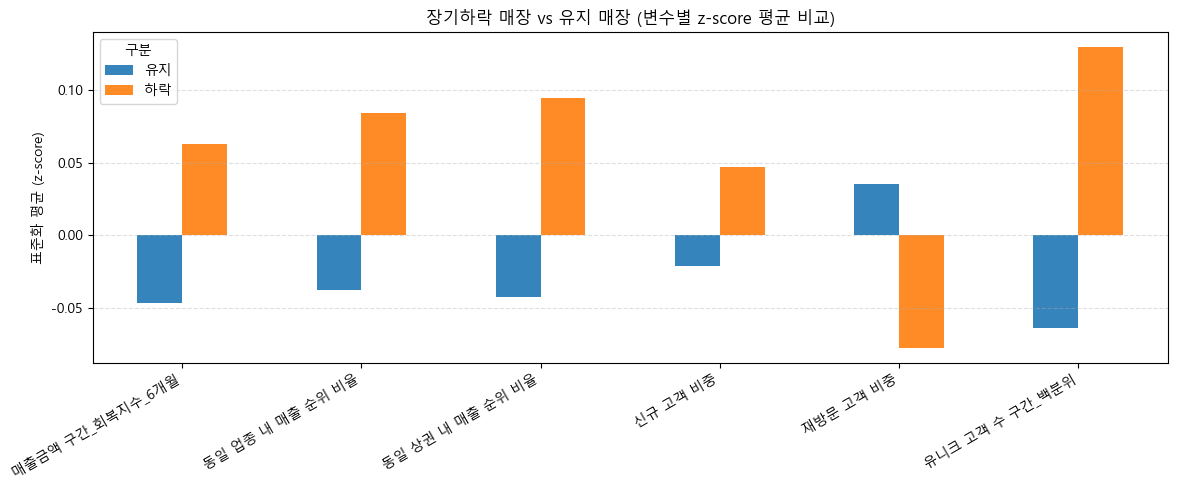

In [87]:
# =============================================
# ✅ 변수별 z-score 후, 장기하락여부 평균 비교 그래프
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) 비교 변수
key_vars = [
    '매출금액 구간_회복지수_6개월',
    '동일 업종 내 매출 순위 비율',
    '동일 상권 내 매출 순위 비율',
    '신규 고객 비중',
    '재방문 고객 비중',
    '유니크 고객 수 구간_백분위'
]

# 1) 장기하락여부 계산(경고 해결 버전)
from sklearn.linear_model import LinearRegression

def slope_last6(g):
    s = g.sort_values('기준년월').tail(6)['매출금액 구간_백분위'].ffill().bfill()
    if s.notna().sum() < 3: 
        return np.nan
    x = np.arange(len(s)).reshape(-1,1)
    y = s.values
    return LinearRegression().fit(x,y).coef_[0]

trend = (df_merged
         .groupby('가맹점구분번호')
         .apply(slope_last6)
         .reset_index(name='추세기울기_6개월'))
trend['장기하락여부'] = (trend['추세기울기_6개월'] < 0).astype(int)

# 2) 원자료에 플래그 머지
base = df_merged.merge(trend[['가맹점구분번호','장기하락여부']], on='가맹점구분번호', how='inner')

# 3) 변수별 z-score (전체 데이터 기준)
Z = base[key_vars].apply(lambda c: (c - c.mean()) / c.std(ddof=0))

# 4) 그룹별 평균 (z-score)
plot_df = pd.concat([base[['장기하락여부']].reset_index(drop=True), Z], axis=1) \
            .groupby('장기하락여부')[key_vars].mean().T \
            .rename(columns={0:'유지', 1:'하락'})

# 5) 시각화
ax = plot_df.plot(kind='bar', figsize=(12,5), alpha=0.9)
plt.title('장기하락 매장 vs 유지 매장 (변수별 z-score 평균 비교)')
plt.ylabel('표준화 평균 (z-score)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='구분')
plt.tight_layout()
plt.show()


### 8. 매출 탄력도

- 종속변수:
매출탄력도
→ 최근 6개월 간 매출금액 구간_백분위의 변동률 표준편차 / 평균값

- 독립변수:
이전 모델들과 동일한 기본 매출 관련 변수들

- 가설:
재방문 고객 비중이 낮고, 업종/상권 내 순위 변동이 큰 매장은
매출 탄력도가 높다 (= 불안정하다).

C:\Users\askie\AppData\Local\Temp\ipykernel_77944\583448532.py:20: RuntimeWarning: invalid value encountered in scalar divide
  return vals.pct_change().std() / abs(vals.pct_change().mean())
C:\Users\askie\AppData\Local\Temp\ipykernel_77944\583448532.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(elasticity)


✅ 분석 데이터 수: 463

=== 📊 매출탄력도 영향 요인 (RandomForest) ===
                   변수       중요도
8    동일 상권 내 매출 순위 비율  0.181097
0            신규 고객 비중  0.176714
7    동일 업종 내 매출 순위 비율  0.169690
6    매출금액 구간_회복지수_6개월  0.167364
4           배달매출금액 비율  0.074097
1           재방문 고객 비중  0.068149
10  동일 상권 내 해지 가맹점 비중  0.045953
9   동일 업종 내 해지 가맹점 비중  0.045731
5         매출건수 구간_백분위  0.033236
2     유니크 고객 수 구간_백분위  0.020450
3          객단가 구간_백분위  0.017519

모델 설명력 R²: 0.897


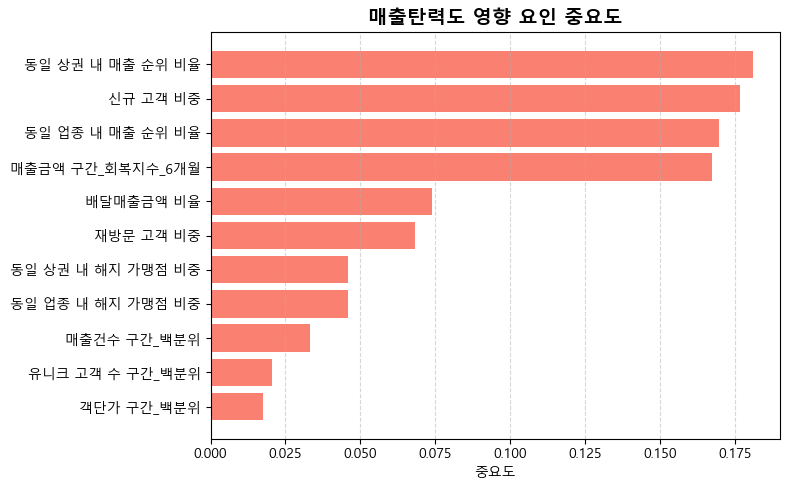

In [88]:
# ============================================
# 💡 매출 탄력도(Elasticity) 분석
# ============================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1️⃣ 최근 6개월 단위로 매출 변동률 표준편차 계산
df_elastic = df_merged.copy()
df_elastic['기준년월'] = pd.to_datetime(df_elastic['기준년월'])
df_elastic = df_elastic.sort_values(['가맹점구분번호', '기준년월'])

# 매출탄력도 = (6개월간 백분위 변화 표준편차 / 평균)
def elasticity(g):
    vals = g['매출금액 구간_백분위'].tail(6)
    if vals.isna().sum() > 0 or vals.mean() == 0:
        return np.nan
    return vals.pct_change().std() / abs(vals.pct_change().mean())

elastic_df = (
    df_elastic.groupby('가맹점구분번호')
    .apply(elasticity)
    .reset_index(name='매출탄력도')
)

# 2️⃣ 최근 시점 데이터와 병합
df_elastic_latest = (
    df_elastic.sort_values(['가맹점구분번호', '기준년월'])
    .groupby('가맹점구분번호').tail(1)
)

df_elastic_merged = df_elastic_latest.merge(elastic_df, on='가맹점구분번호', how='inner')

# 3️⃣ 결측 제거
feature_cols = [
    '신규 고객 비중', '재방문 고객 비중', '유니크 고객 수 구간_백분위',
    '객단가 구간_백분위', '배달매출금액 비율', '매출건수 구간_백분위',
    '매출금액 구간_회복지수_6개월', '동일 업종 내 매출 순위 비율',
    '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
    '동일 상권 내 해지 가맹점 비중'
]

df_elastic_model = df_elastic_merged[['매출탄력도'] + feature_cols].dropna()
print(f"✅ 분석 데이터 수: {df_elastic_model.shape[0]}")

# 4️⃣ 회귀 모델로 영향도 분석
X = df_elastic_model[feature_cols]
y = df_elastic_model['매출탄력도']

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)
r2 = rf.score(X, y)

imp = pd.DataFrame({
    '변수': X.columns,
    '중요도': rf.feature_importances_
}).sort_values('중요도', ascending=False)

print("\n=== 📊 매출탄력도 영향 요인 (RandomForest) ===")
print(imp)
print(f"\n모델 설명력 R²: {r2:.3f}")

# 5️⃣ 시각화 (중요도)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(imp['변수'], imp['중요도'], color='salmon')
plt.gca().invert_yaxis()
plt.title('매출탄력도 영향 요인 중요도', fontsize=14, weight='bold')
plt.xlabel('중요도')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
